```markdown
# Modelo Predictivo del Costo de Casas

Este notebook tiene como objetivo construir y comparar modelos predictivos para estimar el costo de las casas o predios, utilizando Regresión Lineal y Árboles de Decisión.
```

```markdown
## 1. Configuración Inicial y Carga de Datos

Primero, importaremos las librerías necesarias y realizaremos una exploración inicial del dataset.
```

In [2]:
# Importar las librerías necesarias para manipulación de datos y modelado
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar las primeras 5 filas del DataFrame para entender su estructura
# Esto nos ayuda a ver las columnas disponibles y los tipos de datos iniciales.
display(df.head())

# Obtener información concisa del DataFrame, incluyendo tipos de datos y valores no nulos
# Es crucial para identificar columnas con valores faltantes o tipos de datos incorrectos.
print(df.info())

# Generar estadísticas descriptivas del DataFrame
# Proporciona un resumen estadístico de las columnas numéricas, útil para entender la distribución de los datos.
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       2000 non-null   float64
 1   HouseAge     2000 non-null   float64
 2   AveRooms     2000 non-null   float64
 3   AveBedrms    2000 non-null   float64
 4   Population   2000 non-null   float64
 5   AveOccup     2000 non-null   float64
 6   Latitude     2000 non-null   float64
 7   Longitude    2000 non-null   float64
 8   MedHouseVal  2000 non-null   float64
dtypes: float64(9)
memory usage: 140.8 KB
None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.847859,28.781500,5.400407,1.093381,1411.951500,2.958053,35.585255,-119.516540,2.066267
std,1.953553,12.457381,2.106935,0.363481,1059.560242,1.958266,2.145766,1.999785,1.155031
min,0.499900,1.000000,1.972644,0.500000,8.000000,1.263566,32.540000,-124.190000,0.300000
25%,2.562500,18.750000,4.386831,1.004235,787.750000,2.424136,33.930000,-121.755000,1.188000
50%,3.460450,29.000000,5.148772,1.046175,1155.000000,2.815687,34.230000,-118.470000,1.799000
75%,4.635350,37.000000,6.009612,1.097096,1707.000000,3.281427,37.710000,-117.990000,2.644500
max,15.000100,52.000000,41.333333,8.476190,10493.000000,83.171429,41.810000,-114.580000,5.000010


```markdown
## 2. Preprocesamiento de Datos

Definiremos las características (variables independientes) y la variable objetivo (variable dependiente), y luego dividiremos el dataset en conjuntos de entrenamiento y prueba.
```

In [3]:
# Definir las características (X) y la variable objetivo (y)
# 'MedHouseVal' se asume como la variable a predecir (costo de la casa).
# El resto de las columnas son las características que usaremos para la predicción.
X = df.drop('MedHouseVal', axis=1) # Elimina la columna objetivo para obtener las características
y = df['MedHouseVal'] # Selecciona la columna objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba
# Un 80% de los datos se usará para entrenar el modelo y un 20% para evaluarlo.
# `random_state` asegura que la división sea la misma cada vez que se ejecuta el código, para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimir las formas de los conjuntos para verificar que la división se realizó correctamente
# Esto confirma el número de filas y columnas en cada conjunto.
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_test: {X_test.shape}')
print(f'Forma de y_train: {y_train.shape}')
print(f'Forma de y_test: {y_test.shape}')

Forma de X_train: (1600, 8)
Forma de X_test: (400, 8)
Forma de y_train: (1600,)
Forma de y_test: (400,)


```markdown
## 3. Entrenamiento y Evaluación del Modelo de Regresión Lineal

Ahora, entrenaremos un modelo de Regresión Lineal y evaluaremos su rendimiento.
```

### Rendimiento del Modelo de Regresión Lineal ###
Error Absoluto Medio (MAE): 0.53
Coeficiente de Determinación (R²): 0.63


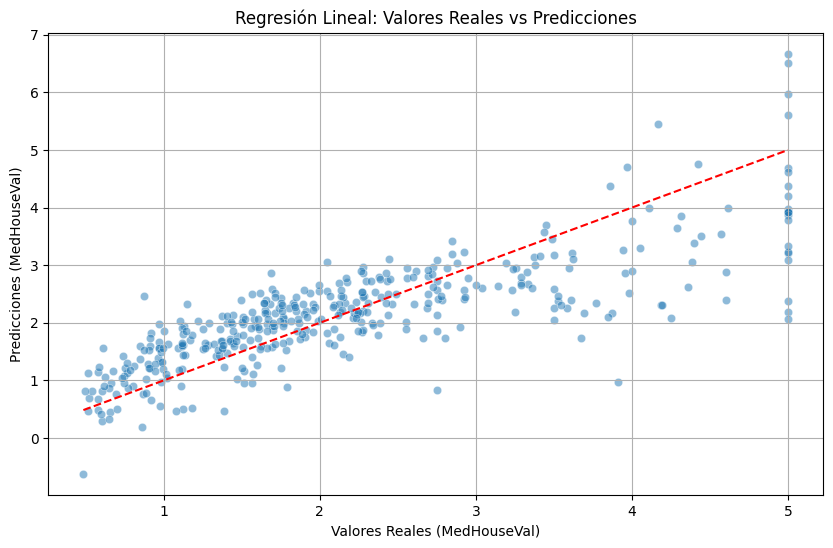

In [4]:
# Inicializar el modelo de Regresión Lineal
# Este modelo lineal trata de encontrar la mejor relación lineal entre las características y la variable objetivo.
linear_model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
# El modelo 'aprende' los patrones de los datos a partir del conjunto de entrenamiento.
linear_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
# Usamos el modelo entrenado para predecir los valores de 'MedHouseVal' en datos no vistos.
y_pred_linear = linear_model.predict(X_test)

# Evaluar el rendimiento del modelo
# Calculamos el Error Absoluto Medio (MAE) y el coeficiente de determinación (R²).
# MAE: Mide la magnitud promedio de los errores en un conjunto de predicciones, sin considerar su dirección.
# R²: Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f'### Rendimiento del Modelo de Regresión Lineal ###')
print(f'Error Absoluto Medio (MAE): {mae_linear:.2f}')
print(f'Coeficiente de Determinación (R²): {r2_linear:.2f}')

# Visualizar las predicciones vs los valores reales
plt.figure(figsize=(10, 6)) # Define el tamaño de la figura para una mejor visualización
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.5) # Crea un gráfico de dispersión de los valores reales vs los predichos
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Dibuja una línea de referencia perfecta (predicciones = reales)
plt.xlabel('Valores Reales (MedHouseVal)') # Etiqueta del eje X
plt.ylabel('Predicciones (MedHouseVal)') # Etiqueta del eje Y
plt.title('Regresión Lineal: Valores Reales vs Predicciones') # Título del gráfico
plt.grid(True) # Muestra una cuadrícula para facilitar la lectura
plt.show() # Muestra el gráfico

```markdown
## 4. Entrenamiento y Evaluación del Modelo de Árbol de Decisión

A continuación, entrenaremos un modelo de Árbol de Decisión y compararemos su rendimiento con el de Regresión Lineal.
```

### Rendimiento del Modelo de Árbol de Decisión ###
Error Absoluto Medio (MAE): 0.54
Coeficiente de Determinación (R²): 0.56


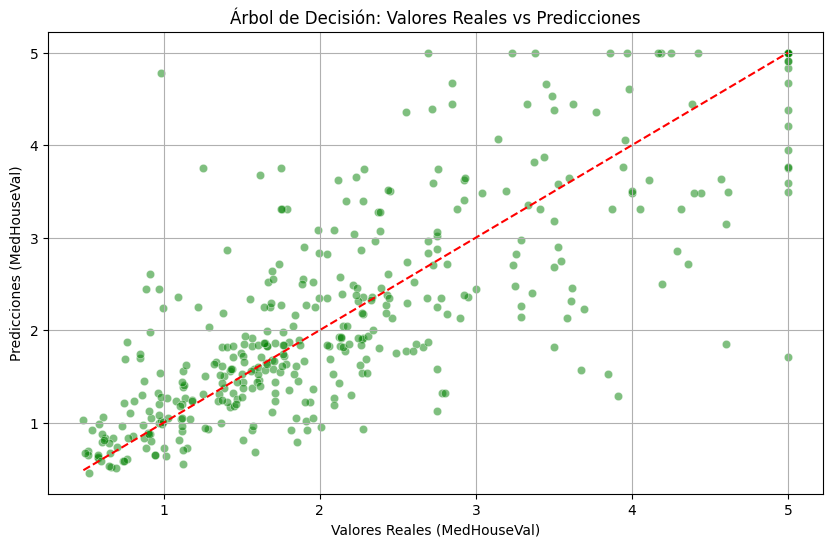

In [5]:
# Inicializar el modelo de Árbol de Decisión
# Los árboles de decisión dividen los datos en ramas basadas en características para predecir un valor objetivo.
# `random_state` se usa para la reproducibilidad de los resultados.
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
# El árbol 'aprende' las reglas de decisión a partir del conjunto de entrenamiento.
decision_tree_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
# Usamos el modelo entrenado para predecir los valores de 'MedHouseVal' en datos no vistos.
y_pred_tree = decision_tree_model.predict(X_test)

# Evaluar el rendimiento del modelo
# Calculamos el Error Absoluto Medio (MAE) y el coeficiente de determinación (R²).
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f'### Rendimiento del Modelo de Árbol de Decisión ###')
print(f'Error Absoluto Medio (MAE): {mae_tree:.2f}')
print(f'Coeficiente de Determinación (R²): {r2_tree:.2f}')

# Visualizar las predicciones vs los valores reales
plt.figure(figsize=(10, 6)) # Define el tamaño de la figura para una mejor visualización
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, color='green') # Crea un gráfico de dispersión con otro color
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Dibuja una línea de referencia perfecta
plt.xlabel('Valores Reales (MedHouseVal)') # Etiqueta del eje X
plt.ylabel('Predicciones (MedHouseVal)') # Etiqueta del eje Y
plt.title('Árbol de Decisión: Valores Reales vs Predicciones') # Título del gráfico
plt.grid(True) # Muestra una cuadrícula
plt.show() # Muestra el gráfico

```markdown
## 5. Comparación y Análisis de Modelos

Finalmente, compararemos el rendimiento de ambos modelos para determinar cuál es más adecuado para esta tarea.
```

In [6]:
# Crear un DataFrame para comparar los resultados de ambos modelos
# Esto facilita la visualización y el análisis de las métricas clave.
comparison_df = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión'],
    'MAE': [mae_linear, mae_tree],
    'R2 Score': [r2_linear, r2_tree]
})

display(comparison_df)

# Análisis de los resultados:
print('\n--- Análisis de Rendimiento ---')
if mae_linear < mae_tree: # Compara el Error Absoluto Medio
    print('El modelo de Regresión Lineal tiene un MAE más bajo, indicando que sus predicciones son, en promedio, más cercanas a los valores reales.')
else:
    print('El modelo de Árbol de Decisión tiene un MAE más bajo, indicando que sus predicciones son, en promedio, más cercanas a los valores reales.')

if r2_linear > r2_tree: # Compara el coeficiente R²
    print('El modelo de Regresión Lineal tiene un R² más alto, lo que significa que explica una mayor proporción de la varianza en el costo de las casas.')
else:
    print('El modelo de Árbol de Decisión tiene un R² más alto, lo que significa que explica una mayor proporción de la varianza en el costo de las casas.')

print('\n--- Consideraciones Adicionales ---')
print('**Regresión Lineal:** Es un modelo simple y fácil de interpretar. Asume una relación lineal entre las variables. Su rendimiento puede ser bueno si esta suposición se cumple.')
print('**Árbol de Decisión:** Puede capturar relaciones no lineales y es más flexible. Sin embargo, puede ser propenso al sobreajuste (overfitting) si no se le restringe la complejidad (por ejemplo, con `max_depth`). Es menos interpretable que la regresión lineal para relaciones complejas.')

print('\nPara decidir el mejor modelo, no solo se deben considerar las métricas numéricas, sino también la interpretabilidad, la complejidad y el riesgo de sobreajuste para el problema específico.')

,Modelo,MAE,R2 Score
0,Regresión Lineal,0.531927,0.634737
1,Árbol de Decisión,0.543486,0.563074



--- Análisis de Rendimiento ---
El modelo de Regresión Lineal tiene un MAE más bajo, indicando que sus predicciones son, en promedio, más cercanas a los valores reales.
El modelo de Regresión Lineal tiene un R² más alto, lo que significa que explica una mayor proporción de la varianza en el costo de las casas.

--- Consideraciones Adicionales ---
**Regresión Lineal:** Es un modelo simple y fácil de interpretar. Asume una relación lineal entre las variables. Su rendimiento puede ser bueno si esta suposición se cumple.
**Árbol de Decisión:** Puede capturar relaciones no lineales y es más flexible. Sin embargo, puede ser propenso al sobreajuste (overfitting) si no se le restringe la complejidad (por ejemplo, con `max_depth`). Es menos interpretable que la regresión lineal para relaciones complejas.

Para decidir el mejor modelo, no solo se deben considerar las métricas numéricas, sino también la interpretabilidad, la complejidad y el riesgo de sobreajuste para el problema específico.
